In [66]:
import os
import subprocess
import baltic as bt
import pandas as pd
import json
from io import StringIO as sio
import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.patheffects as path_effects
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from collections import Counter


Tree height: 0.092300
Tree length: 5.239968
multitype tree
annotations present

Numbers of objects in tree: 6061 (2555 nodes and 3506 leaves)



/var/folders/8v/6y3r5h_x0dv5t5875drggrtc0000gn/T/ipykernel_4460/4060677819.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap('tab20', len(unique_clades))


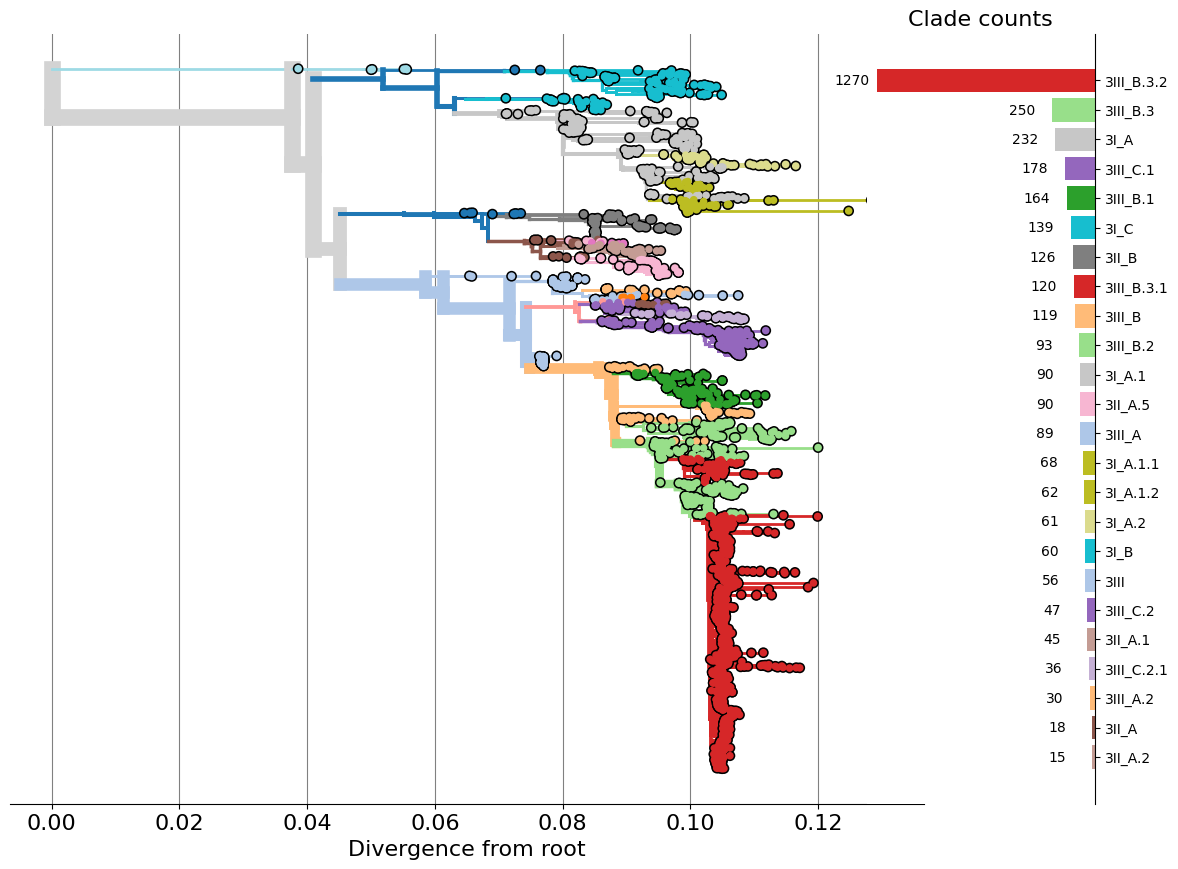

In [84]:
D3_nextstrain = '../Data/D3/D3gisaid_arbo_2025_04_24_18/nextclade.auspice.json'

def prune(node, thresh=0.15):
    # only operate on dict-nodes
    if not isinstance(node, dict):
        return node
    # get the divergence (a float) for *this* branch
    div = node.get('node_attrs', {}) .get('div')
    if div is not None and div > thresh:
        return None
    # otherwise prune children
    if 'children' in node:
        kept = []
        for child in node['children']:
            pc = prune(child, thresh)
            if pc is not None:
                kept.append(pc)
        node['children'] = kept
    return node

# 1) Read the file
with open(D3_nextstrain, 'r') as fh:
    nx_json = json.load(fh)

nx_json['tree'] = prune(nx_json['tree'], thresh=0.15)

# 2) Tell baltic to use 'div' as the node height
json_translation = {
    'absoluteTime': lambda node: node.traits['node_attrs']['div'],
    'name': 'name'
}

# 3) Load into baltic
ll, meta = bt.loadJSON(nx_json, json_translation=json_translation)

# make figure with tree on left and barplot on right
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=-0.1)
ax_tree = fig.add_subplot(gs[0])
ax_bar  = fig.add_subplot(gs[1])


L=len(list(filter(lambda k: k.branchType=='leaf',ll.Objects)))

clade_list = [
    k.traits['node_attrs']
      .get('clade_membership', {})
      .get('value')
    for k in ll.Objects if k.is_leaf()
]

# create a unique sorted list and assign colors from tab20
unique_clades = sorted({c for c in clade_list if c is not None})
palette = cm.get_cmap('tab20', len(unique_clades))
clade_color_map = {
    clade: mcolors.to_hex(palette(i))
    for i, clade in enumerate(unique_clades)
}

# register this map under 'clade_membership'
ll.cmap['clade_membership'] = clade_color_map

clade_counts = Counter(
    node.traits['node_attrs']['clade_membership']['value']
    for node in ll.Objects if node.is_leaf()
)
filtered = {clade: cnt for clade, cnt in clade_counts.items() if cnt >= 10}
clades, counts = zip(*sorted(filtered.items(), key=lambda x: x[1], reverse=True))
colors = [ll.cmap['clade_membership'][c] for c in clades]

# colour function using the newly registered map
def c_func(node):
    clade = node.traits['node_attrs'] \
               .get('clade_membership', {}) \
               .get('value')
    return ll.cmap['clade_membership'].get(clade, 'lightgrey')


x_attr = lambda k: k.absoluteTime
b_func=lambda k: 2+10.0*len(k.leaves)/float(L) if k.branchType=='node' else 2

# plotting
ll.plotTree(ax_tree, x_attr=x_attr, width=b_func, colour=c_func, zorder=20000)
ll.plotPoints(ax_tree, x_attr=x_attr, size=30, colour=c_func, zorder=20002)
for loc in ['left', 'right', 'top']:
    ax_tree.spines[loc].set_visible(False)
ax_tree.grid(axis='x', ls='-', color='grey')
ax_tree.tick_params(axis='y', size=0)
ax_tree.tick_params(axis='x', labelsize=16)
ax_tree.set_xlabel('Divergence from root', fontsize=16)
ax_tree.set_yticklabels([])

y = np.arange(len(clades))
ax_bar.barh(y, counts, color=colors)
ax_bar.set_yticks(y)
ax_bar.set_yticklabels(clades, fontsize=10)
ax_bar.invert_yaxis()

# move y‐labels to the right
ax_bar.yaxis.tick_right()
ax_bar.yaxis.set_label_position('right')
ax_bar.title.set_text('Clade counts')
ax_bar.title.set_size(16)
# make bars extend left
ax_bar.set_xlim(max(counts)*1.05, 0)

# annotate counts at end of each bar
offset = max(counts) * 0.2
for i, count in enumerate(counts):
    ax_bar.text(count + offset, i, str(count),
                va='center', ha='left', fontsize=10)

# drop x‐axis
ax_bar.xaxis.set_visible(False)
for loc in ['bottom', 'top', 'left']:
    ax_bar.spines[loc].set_visible(False)


plt.savefig('../Figures/Supplementary/Dengue3_global.jpeg', dpi = 1200, bbox_inches='tight')
plt.show()